# 📘 Introduction à Python pour la Data Science
## TP : Manipulation du dataset Toyota Used Cars
Ce notebook vous guide dans :
- L'importation des données
- L'exploration
- Le nettoyage
- La visualisation
- Une mini-modélisation Machine Learning

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('toyota.csv')  # Assurez-vous que toyota.csv est dans le même dossier
df=df.copy()
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,GT86,2016,16000,Manual,24089,Petrol,265.0,36.2,2.0
1,GT86,2017,15995,Manual,18615,Petrol,145.0,36.2,2.0
2,GT86,2015,13998,Manual,27469,Petrol,265.0,36.2,2.0
3,GT86,2017,18998,Manual,14736,Petrol,150.0,36.2,2.0
4,GT86,2017,17498,Manual,36284,Petrol,145.0,36.2,2.0


## 🔍 Exploration des données

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6738 entries, 0 to 6737
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         6738 non-null   object 
 1   year          6738 non-null   int64  
 2   price         6738 non-null   int64  
 3   transmission  6738 non-null   object 
 4   mileage       6738 non-null   int64  
 5   fuelType      6738 non-null   object 
 6   tax           6736 non-null   float64
 7   mpg           6738 non-null   float64
 8   engineSize    6738 non-null   float64
dtypes: float64(3), int64(3), object(3)
memory usage: 473.9+ KB


In [29]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,6738.000000,6738.000000,6738.000000,6736.000000,6738.000000,6738.000000
mean,2016.748145,12522.391066,22857.413921,94.683046,63.042223,1.471297
std,2.204062,6345.017587,19125.464147,73.887039,15.836710,0.436159
min,1998.000000,850.000000,2.000000,0.000000,2.800000,0.000000
25%,2016.000000,8290.000000,9446.000000,0.000000,55.400000,1.000000
50%,2017.000000,10795.000000,18513.000000,135.000000,62.800000,1.500000
75%,2018.000000,14995.000000,31063.750000,145.000000,69.000000,1.800000
max,2020.000000,59995.000000,174419.000000,565.000000,235.000000,4.500000


## 🧹 Nettoyage des données:
### 1. Trouver les valeurs manquantes avec " df.isna().sum()
### 2. remplire les valeurs manquantes avec 
```python
df["nom_colonne"]=df['nom_colonne'].fillna(df['nom_colonne'].median()) ou avec mean()
```
### 3. ou supprimer avec la methode dropna() ou cible la colonne 
```python
 df.dropna(subset=['nom_colonne'])```
-

In [30]:
df.isna().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             2
mpg             0
engineSize      0
dtype: int64

In [31]:
# Remplacement simple
df['tax'].fillna(df['tax'].median(), inplace=True)
df.drop_duplicates(inplace=True) # Suppression des doublons
df.isna().sum() #compter les valeurs manquantes aprés nettoyage

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

## 📊 Visualisation

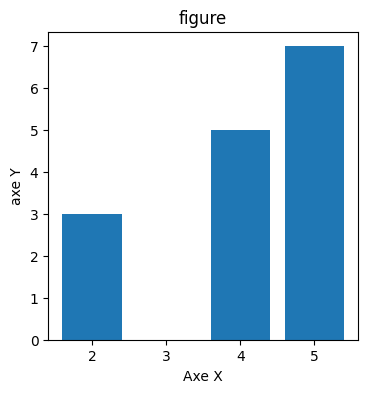

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.title("figure")
plt.bar([2,4,5],[3,5,7])
plt.xlabel("Axe X")
plt.ylabel("axe Y")
plt.show()

In [ ]:
modele_counts = df['model'].value_counts().reset_index()
modele_counts.columns = ['Modèle', 'Nombre']

print(modele_counts)


            Modèle  Nombre
0            Yaris    2117
1             Aygo    1940
2            Auris     709
3             C-HR     479
4             RAV4     467
5          Corolla     265
6            Prius     232
7            Verso     114
8          Avensis     114
9            Hilux      85
10            GT86      73
11    Land Cruiser      51
12    PROACE VERSO      15
13           Supra      12
14           Camry      11
15              IQ       8
16   Urban Cruiser       4
17         Verso-S       3


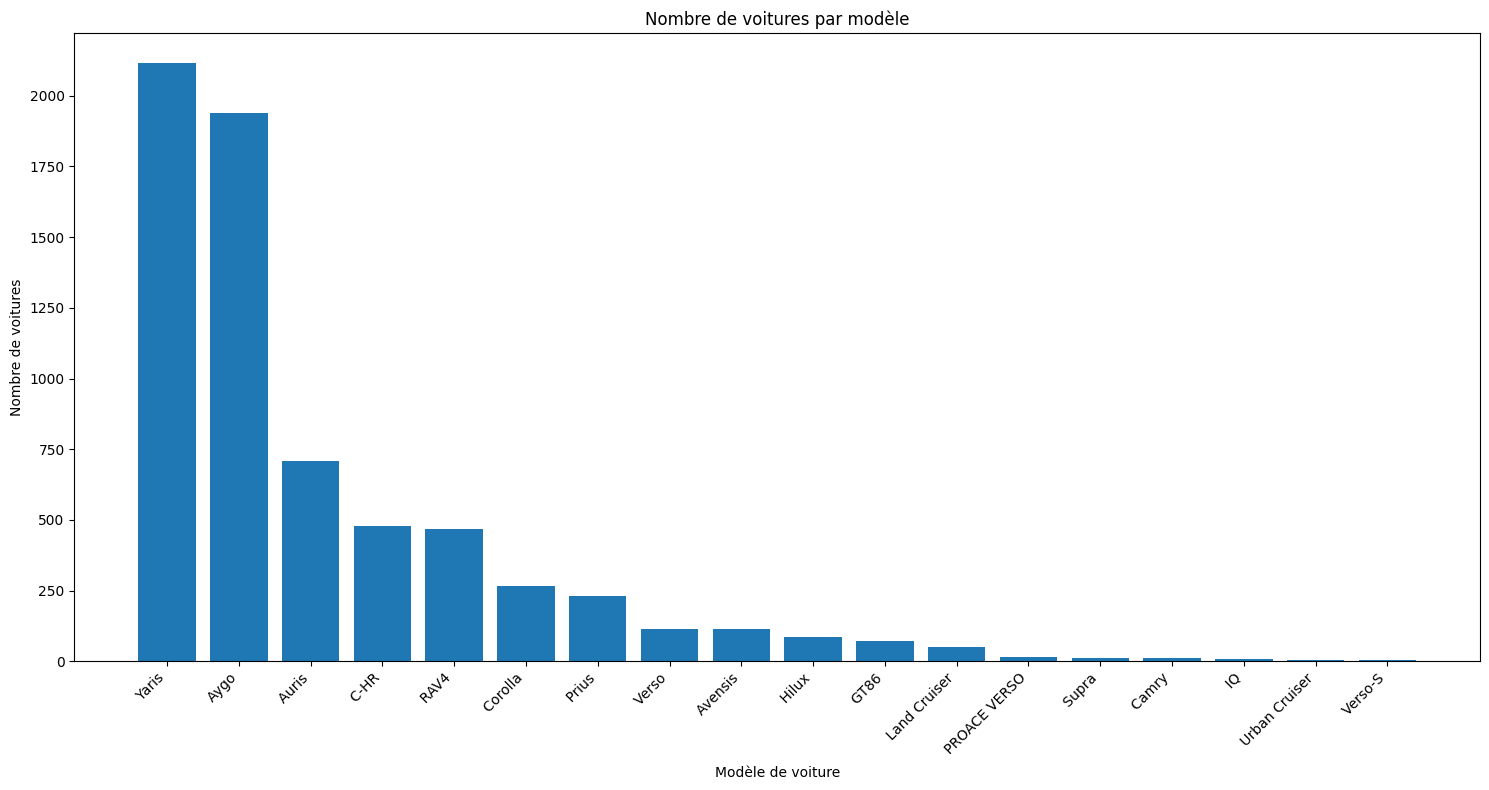

In [33]:

modele_counts = df['model'].value_counts()
plt.figure(figsize=(15, 8))
plt.bar(modele_counts.index, modele_counts.values)

plt.title("Nombre de voitures par modèle")
plt.xlabel("Modèle de voiture")
plt.ylabel("Nombre de voitures")

plt.xticks(rotation=45, ha='right')  # meilleure lisibilité
plt.tight_layout()
plt.show()

## 📊 Répartition des modèles de voitures

Ce code permet de visualiser la distribution des modèles de voitures présents dans le DataFrame.

- Il commence par compter le nombre de voitures pour chaque modèle.
- Ensuite, il crée une figure contenant deux graphiques circulaires (pie charts).

Le premier graphique affiche la répartition de **tous les modèles de voitures** sous forme de pourcentages, ce qui permet d’avoir une vue globale de la distribution.

Le second graphique se concentre uniquement sur les **5 modèles les plus fréquents**, afin de rendre la visualisation plus lisible lorsque le nombre de modèles est élevé.

Ces deux graphiques permettent de comparer la distribution globale des modèles avec celle des modèles les plus représentés.


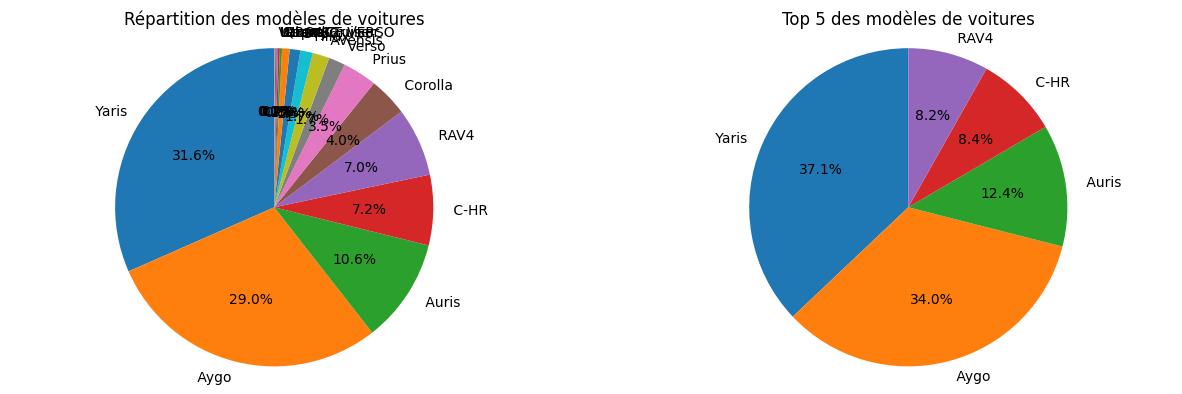

In [34]:
# Compter les occurrences de chaque modèle
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1 )
plt.pie(
    modele_counts,
    labels=modele_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Répartition des modèles de voitures")
plt.axis('equal')  # pour un cercle parfait
plt.subplot(2, 2, 2)
top5 = df['model'].value_counts().head(5)

plt.pie(
    top5,
    labels=top5.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Top 5 des modèles de voitures")
plt.axis('equal')
plt.show()

plt.show()


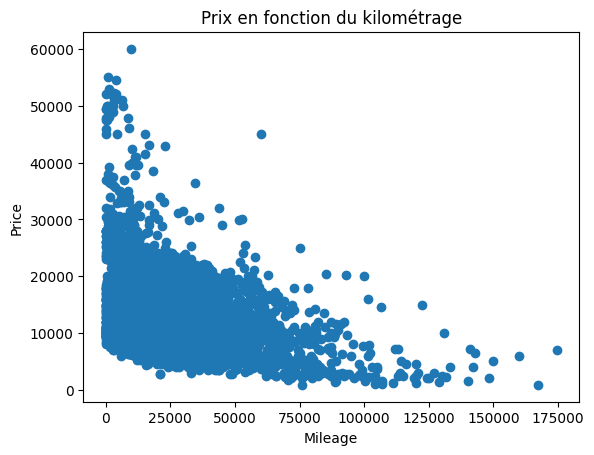

In [35]:
plt.scatter(df['mileage'], df['price'])
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.title('Prix en fonction du kilométrage')
plt.show()

### Densité et Distribution:
- Concentration : La grande majorité des véhicules debase de données ont moins de 75 000 miles.

- Prix Plancher : Au-delà de 125 000 miles, les prix semblent se regrouper massivement en dessous de la barre des 10 000.

                year     price   mileage       tax       mpg  engineSize
year        1.000000  0.422813 -0.726943  0.282560 -0.019372   -0.041643
price       0.422813  1.000000 -0.300598  0.215380 -0.039680    0.728791
mileage    -0.726943 -0.300598  1.000000 -0.204599  0.044419    0.176981
tax         0.282560  0.215380 -0.204599  1.000000 -0.429417    0.157570
mpg        -0.019372 -0.039680  0.044419 -0.429417  1.000000   -0.107048
engineSize -0.041643  0.728791  0.176981  0.157570 -0.107048    1.000000


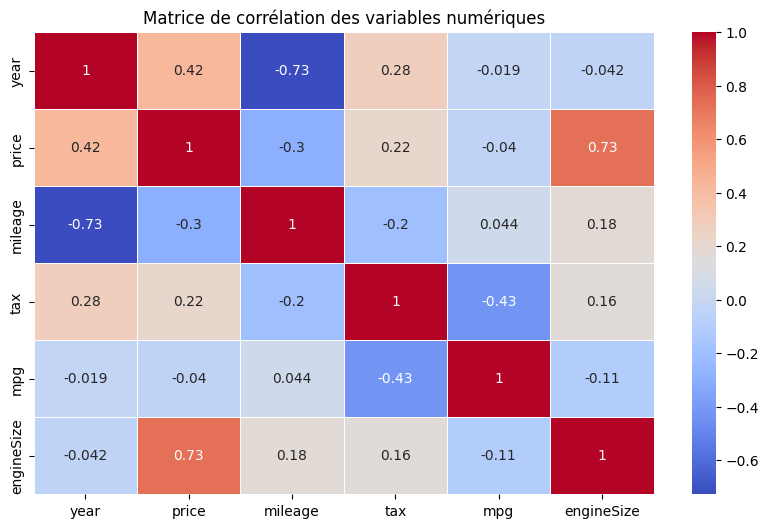

In [36]:
corr = df.corr(numeric_only=True)
print(corr)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Matrice de corrélation des variables numériques")
plt.show()


## Interpretation de correlation entre les variables
Pour rappel, le coefficient de corrélation varie entre -1 et 1 :

- Proche de 1 : Les deux variables augmentent ensemble (forte corrélation positive).

- Proche de -1 : Quand l'une augmente, l'autre diminue (forte corrélation négative).

- Proche de 0 : Il n'y a pas de lien linéaire entre elles.

## 🤖 Mini-modèle Machine Learning (optionnel)

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['mileage', 'year', 'engineSize']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.7757777841247439